In [51]:
!pip install pandas numpy matplotlib seaborn scikit-learn scipy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

df = pd.read_csv('demographic_health_data.csv')
data_dict = pd.read_csv('data_dict.csv', encoding='latin-1')

In [53]:
print("Main dataset shape:", df.shape)
df.head()

Main dataset shape: (3140, 108)


,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,40-49 y/o % of total pop,50-59,50-59 y/o % of total pop,60-69,60-69 y/o % of total pop,70-79,70-79 y/o % of total pop,80+,80+ y/o % of total pop,White-alone pop,% White-alone,Black-alone pop,% Black-alone,Native American/American Indian-alone pop,% NA/AI-alone,Asian-alone pop,% Asian-alone,Hawaiian/Pacific Islander-alone pop,% Hawaiian/PI-alone,Two or more races pop,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Less than a high school diploma 2014-18,High school diploma only 2014-18,Some college or associate's degree 2014-18,Bachelor's degree or higher 2014-18,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,MEDHHINC_2018,CI90LBINC_2018,CI90UBINC_2018,Civilian_labor_force_2018,Employed_2018,Unemployed_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Population Aged 60+,Percent of Population Aged 60+,COUNTY_NAME,STATE_NAME,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,7582,13.636445,7738,13.917016,5826,10.478229,4050,7.284042,2014,3.622237,42660,76.725239,10915,19.630942,267,0.480207,681,1.224798,62,0.111509,1016,1.827305,55601,158,455,11.8,9.6,2.2,0.0,0.7,0.6,4204,12119,10552,10291,11.3,32.6,28.4,27.7,7587,13.8,19.3,19.5,59338,53628,65048,25957,25015,942,3.6,59338,119.0,217.1,196.7,77.2,71.2,7.6,6.9,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,6,55036,10523,19.1,Autauga,Alabama,1,1,42438,47.6,45.4,49.4,20181,35.8,34.2,37.3,15193,7.9,7.2,8.7,3345,8.6,7.3,9.9,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,27338,12.539102,29986,13.753658,29932,13.728890,20936,9.602701,9368,4.296814,190301,87.285228,19492,8.940382,1684,0.772399,2508,1.150343,146,0.066966,3891,1.784682,218022,5403,2190,10.5,10.3,0.1,0.5,24.3,24.8,14310,40579,46025,46075,9.7,27.6,31.3,31.3,21069,9.8,13.9,13.1,57588,54437,60739,93849,90456,3393,3.6,57588,115.5,217.1,196.7,77.2,71.2,7.6,6.9,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,51,203360,53519,26.3,Baldwin,Alabama,1,3,170912,40.2,38.2,42.3,68790,29.7,28.4,31.0,50761,7.8,7.0,8.7,13414,8.6,7.2,10.1,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,3074,12.354809,3278,13.174712,3076,12.3

In [54]:
data_dict.head(20)

,Feature,Unnamed: 1,Unnamed: 2
0,fips,FIPS Code for the County,NaN
1,TOT_POP,Total Population,This data as well as all Age and Race data is ...
2,0-9,Population aged 0-9,All of the other age columns are the same but ...
3,0-9 y/o % of total pop,% of the population aged 0-9,NaN
4,10-19',NaN,NaN
5,10-19 y/o % of total pop,NaN,NaN
6,20-29,NaN,NaN
7,20-29 y/o % of total pop,NaN,NaN
8,30-39,NaN,NaN
9,30-39 y/o % of total pop,NaN,NaN


# Target Variable Selection

The dataset contains six health outcome variables at the county level:
- `anycondition_prevalence`
- `Obesity_prevalence`
- `Heart disease_prevalence`
- `COPD_prevalence`
- `diabetes_prevalence`
- `CKD_prevalence`

We select **`anycondition_prevalence`** as our target variable for the following reasons:

1. It represents the broadest measure of county-level health burden, capturing the percentage of adults living with at least one chronic condition regardless of which specific condition dominates.
2. The specific condition columns are not independent of each other — comorbidities are correlated by nature (obesity drives diabetes, diabetes drives CKD, etc.), making multi-target modeling with linear algorithms conceptually problematic for this dataset.
3. As the aggregate of the specific conditions, `anycondition_prevalence` captures the overall signal without redundancy.

The research question becomes: **what sociodemographic and health resource factors predict the overall chronic disease burden of a US county?**

In [55]:
target = 'anycondition_prevalence'

X = df.drop(columns=[target])
y = df[target]

print(f"Target: {target}")
print(f"Target shape: {y.shape}")
print(f"Target range: {y.min():.1f} - {y.max():.1f}")
print(f"Target mean: {y.mean():.1f}")
print(f"\nFeatures shape: {X.shape}")

Target: anycondition_prevalence
Target shape: (3140,)
Target range: 22.0 - 66.2
Target mean: 46.8

Features shape: (3140, 107)


# Exploratory Data Analysis

## Step 1: Missing Values

Before any modeling decisions, we need to understand the completeness of the dataset.
Columns with excessive missing values will be dropped. Columns with minor missing values
will be imputed depending on the nature of the data.

In [56]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).sort_values('missing_pct', ascending=False)

missing_df = missing_df[missing_df['missing_count'] > 0]
print(f"Columns with missing values: {len(missing_df)}")
print(missing_df)

Columns with missing values: 0
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []


In [57]:
for i, col in enumerate(df.columns):
    print(f"{i:3d}  {col}")

  0  fips
  1  TOT_POP
  2  0-9
  3  0-9 y/o % of total pop
  4  19-Oct
  5  10-19 y/o % of total pop
  6  20-29
  7  20-29 y/o % of total pop
  8  30-39
  9  30-39 y/o % of total pop
 10  40-49
 11  40-49 y/o % of total pop
 12  50-59
 13  50-59 y/o % of total pop
 14  60-69
 15  60-69 y/o % of total pop
 16  70-79
 17  70-79 y/o % of total pop
 18  80+
 19  80+ y/o % of total pop
 20  White-alone pop
 21  % White-alone
 22  Black-alone pop
 23  % Black-alone
 24  Native American/American Indian-alone pop
 25  % NA/AI-alone
 26  Asian-alone pop
 27  % Asian-alone
 28  Hawaiian/Pacific Islander-alone pop
 29  % Hawaiian/PI-alone
 30  Two or more races pop
 31  % Two or more races
 32  POP_ESTIMATE_2018
 33  N_POP_CHG_2018
 34  GQ_ESTIMATES_2018
 35  R_birth_2018
 36  R_death_2018
 37  R_NATURAL_INC_2018
 38  R_INTERNATIONAL_MIG_2018
 39  R_DOMESTIC_MIG_2018
 40  R_NET_MIG_2018
 41  Less than a high school diploma 2014-18
 42  High school diploma only 2014-18
 43  Some college or associ

## Step 2: Dropping Irrelevant Columns

We drop four categories of columns:
1. **Identifiers** — FIPS codes, county and state names. These label the data but have no predictive value.
2. **Leakage** — The specific condition prevalences (obesity, heart disease, COPD, diabetes, CKD) and all their confidence intervals and raw counts. These are components of our target variable and would constitute data leakage.
3. **Redundant raw counts** — Wherever we have both a raw count and a percentage for the same variable (age groups, race, education, poverty, employment), we keep the percentage as it is normalized across counties of different sizes.
4. **Duplicate columns** — Several variables appear twice under different names (population estimate, median household income). We keep one copy of each.

In [58]:
cols_to_drop = [
    'fips', 'COUNTY_NAME', 'STATE_NAME', 'STATE_FIPS', 'CNTY_FIPS',
    'anycondition_Lower 95% CI', 'anycondition_Upper 95% CI', 'anycondition_number',
    'Obesity_prevalence', 'Obesity_Lower 95% CI', 'Obesity_Upper 95% CI', 'Obesity_number',
    'Heart disease_prevalence', 'Heart disease_Lower 95% CI', 'Heart disease_Upper 95% CI', 'Heart disease_number',
    'COPD_prevalence', 'COPD_Lower 95% CI', 'COPD_Upper 95% CI', 'COPD_number',
    'diabetes_prevalence', 'diabetes_Lower 95% CI', 'diabetes_Upper 95% CI', 'diabetes_number',
    'CKD_prevalence', 'CKD_Lower 95% CI', 'CKD_Upper 95% CI', 'CKD_number',
    '0-9', '19-Oct', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+',
     'White-alone pop', 'Black-alone pop', 'Native American/American Indian-alone pop',
    'Asian-alone pop', 'Hawaiian/Pacific Islander-alone pop', 'Two or more races pop',
    'Less than a high school diploma 2014-18', 'High school diploma only 2014-18',
    'Some college or associate\'s degree 2014-18', 'Bachelor\'s degree or higher 2014-18',
    'POVALL_2018', 'Civilian_labor_force_2018', 'Employed_2018', 'Unemployed_2018',
    'POP_ESTIMATE_2018', 'MEDHHINC_2018', 'CI90LBINC_2018', 'CI90UBINC_2018',
    'Total Active Patient Care Physicians per 100000 Population 2018 (AAMC)',
    'Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC)',
    'Active Patient Care General Surgeons per 100000 Population 2018 (AAMC)',
]

X = X.drop(columns=cols_to_drop)
print(f"Remaining features: {X.shape[1]}")
print(X.columns.tolist())

Remaining features: 49
['TOT_POP', '0-9 y/o % of total pop', '10-19 y/o % of total pop', '20-29 y/o % of total pop', '30-39 y/o % of total pop', '40-49 y/o % of total pop', '50-59 y/o % of total pop', '60-69 y/o % of total pop', '70-79 y/o % of total pop', '80+ y/o % of total pop', '% White-alone', '% Black-alone', '% NA/AI-alone', '% Asian-alone', '% Hawaiian/PI-alone', '% Two or more races', 'N_POP_CHG_2018', 'GQ_ESTIMATES_2018', 'R_birth_2018', 'R_death_2018', 'R_NATURAL_INC_2018', 'R_INTERNATIONAL_MIG_2018', 'R_DOMESTIC_MIG_2018', 'R_NET_MIG_2018', 'Percent of adults with less than a high school diploma 2014-18', 'Percent of adults with a high school diploma only 2014-18', "Percent of adults completing some college or associate's degree 2014-18", "Percent of adults with a bachelor's degree or higher 2014-18", 'PCTPOVALL_2018', 'PCTPOV017_2018', 'PCTPOV517_2018', 'Unemployment_rate_2018', 'Median_Household_Income_2018', 'Med_HH_Income_Percent_of_State_Total_2018', 'Active Physicians

## Step 3: Target Variable Distribution

Before modeling, we need to understand the distribution of our target variable.
A roughly normal distribution is ideal for linear regression. We check for skewness,
outliers, and overall shape.

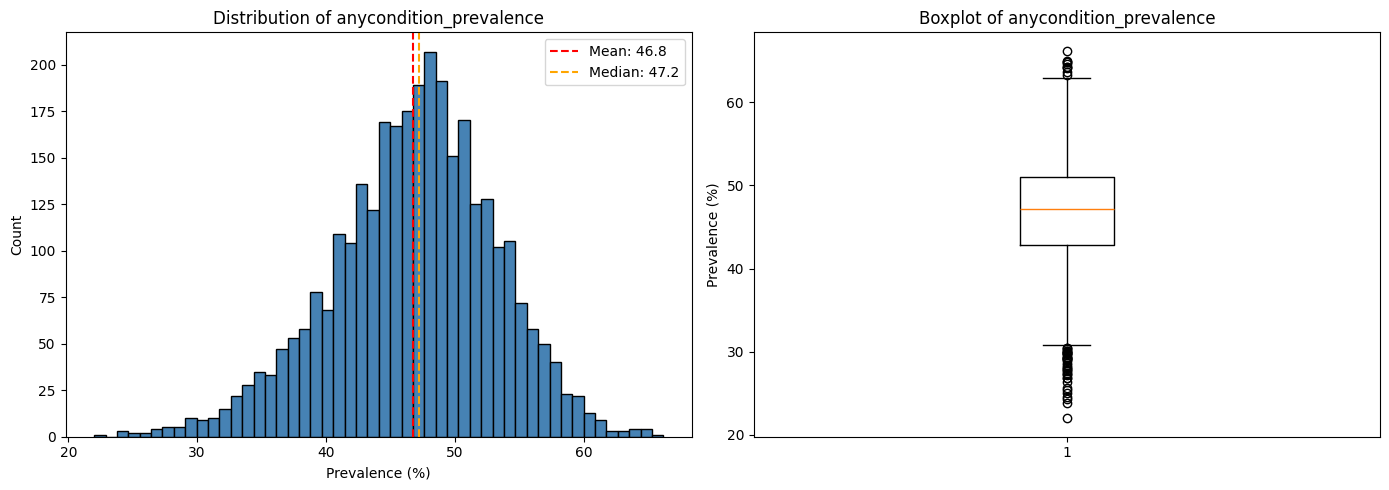

Mean:       46.79
Median:     47.20
Std:        6.38
Skewness:   -0.34


In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y, bins=50, edgecolor='black', color='steelblue')
axes[0].set_title('Distribution of anycondition_prevalence')
axes[0].set_xlabel('Prevalence (%)')
axes[0].set_ylabel('Count')
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Mean: {y.mean():.1f}')
axes[0].axvline(y.median(), color='orange', linestyle='--', label=f'Median: {y.median():.1f}')
axes[0].legend()

axes[1].boxplot(y, vert=True)
axes[1].set_title('Boxplot of anycondition_prevalence')
axes[1].set_ylabel('Prevalence (%)')

plt.tight_layout()
plt.show()

print(f"Mean:       {y.mean():.2f}")
print(f"Median:     {y.median():.2f}")
print(f"Std:        {y.std():.2f}")
print(f"Skewness:   {y.skew():.2f}")

## Step 4: Feature Distributions and Correlation with Target

We examine how each feature correlates with `anycondition_prevalence`.
This helps us understand which variables are likely to be strong predictors
and identify any features with near-zero variance that would contribute nothing to the model.

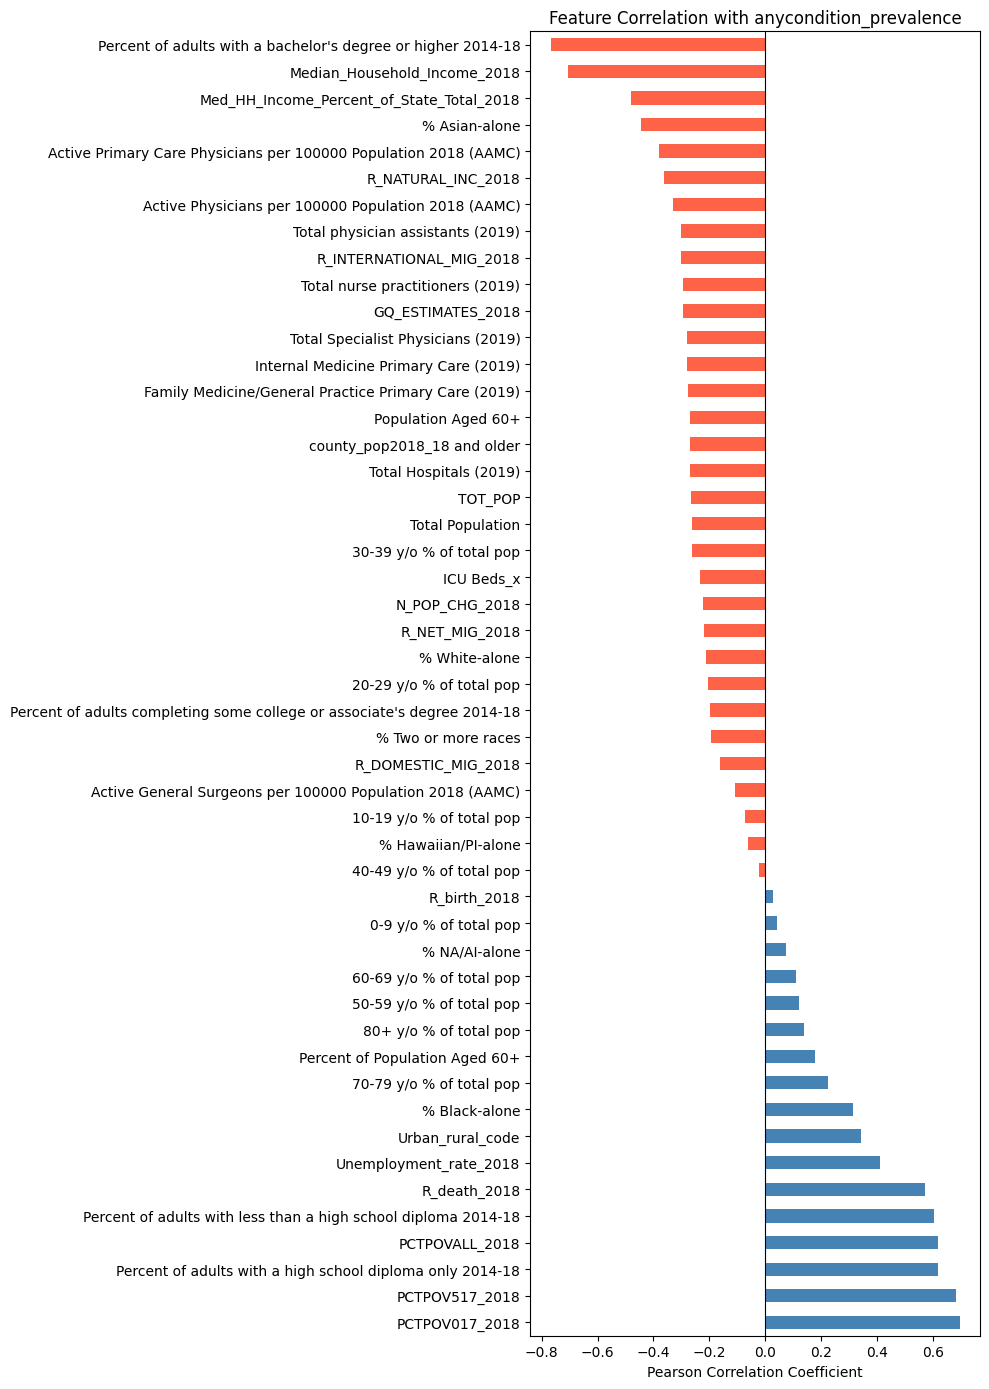

Top 10 positive correlations:
PCTPOV017_2018                                                    0.694607
PCTPOV517_2018                                                    0.681035
Percent of adults with a high school diploma only 2014-18         0.619251
PCTPOVALL_2018                                                    0.617216
Percent of adults with less than a high school diploma 2014-18    0.603561
R_death_2018                                                      0.570435
Unemployment_rate_2018                                            0.409844
Urban_rural_code                                                  0.342133
% Black-alone                                                     0.313323
70-79 y/o % of total pop                                          0.223245
dtype: float64

Top 10 negative correlations:
Total nurse practitioners (2019)                                   -0.294007
R_INTERNATIONAL_MIG_2018                                           -0.302757
Total physician assi

In [60]:
correlations = X.corrwith(y).sort_values(ascending=False)

plt.figure(figsize=(10, 14))
correlations.plot(kind='barh', color=['steelblue' if c > 0 else 'tomato' for c in correlations])
plt.title('Feature Correlation with anycondition_prevalence')
plt.xlabel('Pearson Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("Top 10 positive correlations:")
print(correlations.head(10))
print("\nTop 10 negative correlations:")
print(correlations.tail(10))

## Step 5: Train/Test Split

We split the data into training and test sets before any further processing or modeling.
This ensures that no information from the test set leaks into our training process.
We use an 80/20 split, which is standard for a dataset of this size (3,140 counties).
The random state is fixed for reproducibility.

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set:           {X_train.shape[0]} rows, {X_train.shape[1]} columns")
print(f"Test set:               {X_test.shape[0]} rows, {X_test.shape[1]} columns")
print(f"\nTraining target mean: {y_train.mean():.2f}")
print(f"Test target mean:       {y_test.mean():.2f}")

Training set:           2512 rows, 49 columns
Test set:               628 rows, 49 columns

Training target mean: 46.76
Test target mean:       46.92


## Step 6: Feature Scaling

Before training any model, we scale our features using StandardScaler.
This transforms each feature to have mean=0 and standard deviation=1.

This is essential for Lasso regression because the regularization penalty is applied
equally to all coefficients. If features are on different scales (e.g., Median Household
Income in the tens of thousands vs. percentage values between 0-100), Lasso will
unfairly penalize the coefficients of large-scale features. Scaling ensures the penalty
is applied fairly across all features.

We fit the scaler ONLY on the training set, then apply it to both train and test sets.
Fitting on the full dataset before splitting would leak test set statistics into training,
which is a form of data leakage.

In [62]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print(f"Training set mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Training set std  (should be ~1): {X_train_scaled.std():.4f}")

Scaling complete.
Training set mean (should be ~0): 0.0000
Training set std  (should be ~1): 1.0000


## Step 7: Baseline Linear Regression Model

We begin with a standard linear regression model using all 49 features and default parameters.
This gives us a baseline performance benchmark that we will use to compare against the
regularized Lasso model. We evaluate using R² (proportion of variance explained) and
RMSE (root mean squared error, in the same units as our target — percentage points).

In [63]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_train = lr.predict(X_train_scaled)
y_pred_test = lr.predict(X_test_scaled)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("Baseline Linear Regression Results")
print(f"    Train R^2:  {r2_train:.4f}")
print(f"    Test R^2:   {r2_test:.4f}")
print(f"    Train RMSE: {rmse_train:.4f}")
print(f"    Test RMSE:  {rmse_test:.4f}")
print(f"\n  Difference in R^2 (train - test): {r2_train - r2_test:.4f}")

Baseline Linear Regression Results
    Train R^2:  0.7943
    Test R^2:   0.7986
    Train RMSE: 2.8929
    Test RMSE:  2.8612

  Difference in R^2 (train - test): -0.0043


## Step 8: Lasso Regression Model

Lasso (Least Absolute Shrinkage and Selection Operator) adds a regularization penalty
to the linear regression cost function that shrinks coefficients toward zero, and can
drive weakly predictive features to exactly zero — effectively performing automatic
feature selection. We first run Lasso with default parameters (alpha=1.0) and compare
against the baseline linear regression.

In [64]:
lasso = Lasso(random_state=42)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso_train = lasso.predict(X_train_scaled)
y_pred_lasso_test = lasso.predict(X_test_scaled)

r2_lasso_train = r2_score(y_train, y_pred_lasso_train)
r2_lasso_test = r2_score(y_test, y_pred_lasso_test)
rmse_lasso_train = np.sqrt(mean_squared_error(y_train, y_pred_lasso_train))
rmse_lasso_test = np.sqrt(mean_squared_error(y_test, y_pred_lasso_test))

zeroed = np.sum(lasso.coef_ == 0)

print("Lasso Regression Results (alpha=1.0):")
print(f"    Train R^2:  {r2_lasso_train:.4f}")
print(f"    Test R^2:   {r2_lasso_test:.4f}")
print(f"    Train RMSE: {rmse_lasso_train:.4f}")
print(f"    Test RMSE:  {rmse_lasso_test:.4f}")
print(f"    Features zeroed out: {zeroed} of {X_train.shape[1]}")

print("\nComparison:")
print(f"    Linear Regression Test R^2:  {r2_test:.4f}")
print(f"    Lasso Test R^2:              {r2_lasso_test:.4f}")
print(f"    Difference:                  {r2_lasso_test - r2_test:.4f}")

Lasso Regression Results (alpha=1.0):
    Train R^2:  0.6815
    Test R^2:   0.6822
    Train RMSE: 3.5999
    Test RMSE:  3.5942
    Features zeroed out: 46 of 49

Comparison:
    Linear Regression Test R^2:  0.7986
    Lasso Test R^2:              0.6822
    Difference:                  -0.1164


## Step 9: Lasso Model Analysis

With default parameters (alpha=1.0) and properly scaled features, Lasso zeroed out
46 of 49 features — retaining only 3 to predict chronic disease prevalence. While the
model still explains 68% of variance with near-zero overfitting (train/test R² difference
of 0.0007), the performance cost compared to baseline linear regression is significant
(-0.1164 R²).

This tells us that alpha=1.0 is too aggressive for this dataset. The penalty is so strong
that it is discarding genuinely useful predictive information. We need to find the optimal
alpha value — one that balances regularization (feature reduction, overfitting prevention)
against predictive performance (R²).

In the next step we sweep alpha from 0.0 to 20.0 and observe how R² evolves on both
the training and test sets to find that balance point.

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.052e+04, tolerance: 1.022e+01
  model = cd_fast.enet_coordinate_descent(


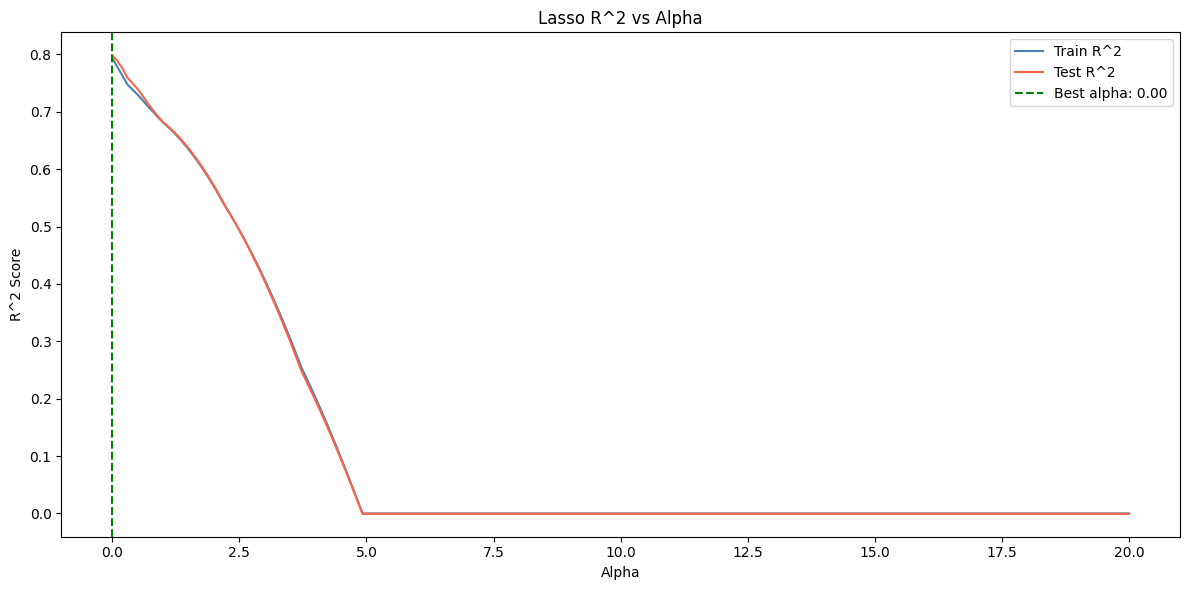

Best alpha (max test R^2):  0.0000
Best test R^2:              0.7986
Baseline linear test R^2:   0.7986


In [65]:
alphas = np.linspace(0.0, 20.0, 200)
r2_train_scores = []
r2_test_scores = []

for alpha in alphas:
    lasso_sweep = Lasso(alpha=alpha if alpha > 0 else 1e-10, random_state=42, max_iter=10000)
    lasso_sweep.fit(X_train_scaled, y_train)
    r2_train_scores.append(r2_score(y_train, lasso_sweep.predict(X_train_scaled)))
    r2_test_scores.append(r2_score(y_test, lasso_sweep.predict(X_test_scaled)))

plt.figure(figsize=(12, 6))
plt.plot(alphas, r2_train_scores, label='Train R^2', color='steelblue')
plt.plot(alphas, r2_test_scores, label='Test R^2', color='tomato' )
plt.axvline(alphas[np.argmax(r2_test_scores)], color='green', linestyle='--', label=f'Best alpha: {alphas[np.argmax(r2_test_scores)]:.2f}')
plt.xlabel('Alpha')
plt.ylabel('R^2 Score')
plt.title('Lasso R^2 vs Alpha')
plt.legend()
plt.tight_layout()
plt.show()

best_alpha = alphas[np.argmax(r2_test_scores)]
print(f"Best alpha (max test R^2):  {best_alpha:.4f}")
print(f"Best test R^2:              {max(r2_test_scores):.4f}")
print(f"Baseline linear test R^2:   {r2_test:.4f}")

## Step 10: Lasso Optimization with LassoCV

The alpha sweep demonstrated that default alpha=1.0 is too aggressive for this dataset,
and that any substantial regularization hurts performance. However, a manual sweep is a
blunt instrument — it tests evenly spaced values without accounting for how the model
actually generalizes across different subsets of the data.

LassoCV addresses this by using cross-validation to find the optimal alpha. It tests
multiple alpha values across k folds of the training data, selecting the alpha that
produces the best average performance across all folds rather than on a single
train/test split. This gives us a more statistically robust optimal alpha.

In [66]:
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)

y_pred_lassocv_train = lasso_cv.predict(X_train_scaled)
y_pred_lassocv_test = lasso_cv.predict(X_test_scaled)

r2_lassocv_train = r2_score(y_train, y_pred_lassocv_train)
r2_lassocv_test = r2_score(y_test, y_pred_lassocv_test)

rmse_lassocv_train = np.sqrt(mean_squared_error(y_train, y_pred_lassocv_train))
rmse_lassocv_test = np.sqrt(mean_squared_error(y_test, y_pred_lassocv_test))
zeroed_cv = np.sum(lasso_cv.coef_ == 0)

print(f"LassoCV optimal alpha: {lasso_cv.alpha_:.6f}")
print(f"\nLassoCV Results:")
print(f"  Train R2:            {r2_lassocv_train:.4f}")
print(f"  Test R2:             {r2_lassocv_test:.4f}")
print(f"  Train RMSE:          {rmse_lassocv_train:.4f}")
print(f"  Test RMSE:           {rmse_lassocv_test:.4f}")
print(f"  Features zeroed out: {zeroed_cv} of {X_train.shape[1]}")

print(f"\nFinal Model Comparison:")
print(f"  Baseline Linear Regression Test R2: {r2_test:.4f}")
print(f"  Lasso (alpha=1.0) Test R2:          {r2_lasso_test:.4f}")
print(f"  LassoCV (optimal alpha) Test R2:    {r2_lassocv_test:.4f}")


LassoCV optimal alpha: 0.032370

LassoCV Results:
  Train R2:            0.7886
  Test R2:             0.7960
  Train RMSE:          2.9331
  Test RMSE:           2.8798
  Features zeroed out: 20 of 49

Final Model Comparison:
  Baseline Linear Regression Test R2: 0.7986
  Lasso (alpha=1.0) Test R2:          0.6822
  LassoCV (optimal alpha) Test R2:    0.7960


## Summary and Conclusions

### Model Performance

Three models were trained to predict county-level chronic condition prevalence
(`anycondition_prevalence`) across 3,140 US counties using sociodemographic and
health resource features.

| Model | Test R² | Test RMSE | Features Used |
|-------|---------|-----------|---------------|
| Baseline Linear Regression | 0.7986 | 2.8608 | 49 of 49 |
| Lasso (alpha=1.0) | 0.6822 | 3.5942 | 3 of 49 |
| LassoCV (alpha=0.0324) | 0.7960 | 2.8798 | 29 of 49 |

LassoCV is the optimal model — it explains 79.6% of the variance in county-level
chronic disease burden while using only 29 features, at a cost of just 0.0026 R²
compared to the full baseline model.

### Key Findings from EDA

The correlation analysis revealed a clear hierarchy of predictors:

**Sociodemographic factors dominate:**
- Child poverty rate (r=0.69) and overall poverty (r=0.62) are the strongest
  positive predictors of chronic disease burden
- Bachelor's degree attainment (r=-0.77) and median household income (r=-0.71)
  are the strongest negative predictors
- Rural counties (higher Urban_rural_code) show systematically higher chronic
  disease prevalence (r=0.34)

**Health resources matter, but less than expected:**
- Active physicians per 100k (r=-0.33) and primary care physicians (r=-0.38)
  correlate with lower chronic disease burden
- However, these effects are notably weaker than poverty and education
- This suggests that health resource availability is partially a downstream
  consequence of the same socioeconomic conditions that drive chronic disease,
  rather than an independent protective factor

### Interpretation

The data tells a consistent story: chronic disease burden in US counties is
primarily driven by socioeconomic conditions — poverty, education, and income —
rather than by the availability of healthcare resources. Counties with more
physicians and hospitals do show better health outcomes, but the effect is
secondary to the underlying social determinants of health.

This has implications for public health policy: improving healthcare access alone
is unlikely to close the gap between high and low burden counties without
simultaneously addressing the socioeconomic conditions that drive chronic disease
in the first place.